In [224]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
from vip_slap2_analysis.glutamate.summary import GlutamateSummary

import seaborn as sns

from PNW_cmap import PNW_cmap
sns.set_style('white')
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
plt.rcParams.update(params)

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
%matplotlib notebook

In [4]:
basepath = r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics"
summary_path = glob.glob(os.path.join(basepath,'**summary.xlsx'))[0]
summary_df = pd.read_excel(summary_path,sheet_name='subjects')
session_df = pd.read_excel(summary_path,sheet_name='sessions')

In [186]:
target_mouse = 834788

session_paths = session_df[session_df['subject_id']==target_mouse]['session_dir'].values
summary_datapaths = [glob.glob(os.path.join(p,'**','SummaryLoCo**.mat'),recursive=True) for p in session_paths]
summary_datapaths = [x for l in summary_datapaths for x in l]
summary_datapaths

['\\\\allen\\aind\\scratch\\ophys\\Andrew\\VIP_synaptic_dynamics\\iGluSnFR4f+RCaMP3\\834788\\834788_2026-03-02_10-18-42\\834788_2026-03-02_10-18-42_slap2_2026-03-02_10-18-42\\source_extraction\\ExperimentSummary\\SummaryLoCo-260303-084206.mat',
 '\\\\allen\\aind\\scratch\\ophys\\Andrew\\VIP_synaptic_dynamics\\iGluSnFR4f+RCaMP3\\834788\\834788_2026-03-03_09-22-19\\834788_2026-03-03_09-22-19_slap2_2026-03-03_09-22-19\\source_extraction\\ExperimentSummary\\SummaryLoCo-260304-143814.mat',
 '\\\\allen\\aind\\scratch\\ophys\\Andrew\\VIP_synaptic_dynamics\\iGluSnFR4f+RCaMP3\\834788\\834788_2026-03-04_08-43-07\\834788_2026-03-04_08-43-07_slap2_2026-03-04_08-43-07\\source_extraction\\ExperimentSummary\\SummaryLoCo-260305-101229.mat',
 '\\\\allen\\aind\\scratch\\ophys\\Andrew\\VIP_synaptic_dynamics\\iGluSnFR4f+RCaMP3\\834788\\834788_2026-03-05_08-11-16\\834788_2026-03-05_08-11-16_slap2_2026-03-05_08-11-16\\source_extraction\\ExperimentSummary\\SummaryLoCo-260307-110926.mat',
 '\\\\allen\\aind\\s

In [320]:
datapath = summary_datapaths[2]

In [321]:
gs = GlutamateSummary(datapath, keep_open=True)
valid_trials_dmd1 = gs.valid_trials[0]
valid_trials_dmd2 = gs.valid_trials[1]
print(gs.n_synapses)          # list per DMD
print(gs.valid_trials[1])     # trials for DMD1

# Get dF/ls traces, all channels:
X = gs.get_traces(dmd=1, trial=valid_trials_dmd1[0], signal="dF",mode='ls', force_n_channels=2)

# X is (samples, rois, channels) OR (samples, rois) if single-channel

# Only green channel:
Xg = gs.get_traces(dmd=1, trial=valid_trials_dmd1[0], signal="dF", mode="ls", channels="green")

# User ROI traces (e.g. soma ROI):
U = gs.get_user_roi_traces(dmd=1, trial=valid_trials_dmd1[0], trace_type="F", channels=None)

# Summary image:
mean_im = gs.get_summary_image(dmd=1, image_type="meanIM")
act_im  = gs.get_summary_image(dmd=1, image_type="actIM")


[64, 37]
[3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 27, 28, 34, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 52, 53, 54, 55, 56, 58, 59, 60, 61, 62, 63, 64, 65]


In [322]:
X.shape
# X[:,:,0]

(5539, 64, 2)

In [323]:
im = gs.get_summary_image(dmd=1,image_type='meanIM')[::,0,::]
im = np.nan_to_num(im, nan=0.0)

In [324]:
cl,cmap,cp = PNW_cmap.get_PNW_cmap('Sunset',n_colors=10)

<IPython.core.display.Javascript object>


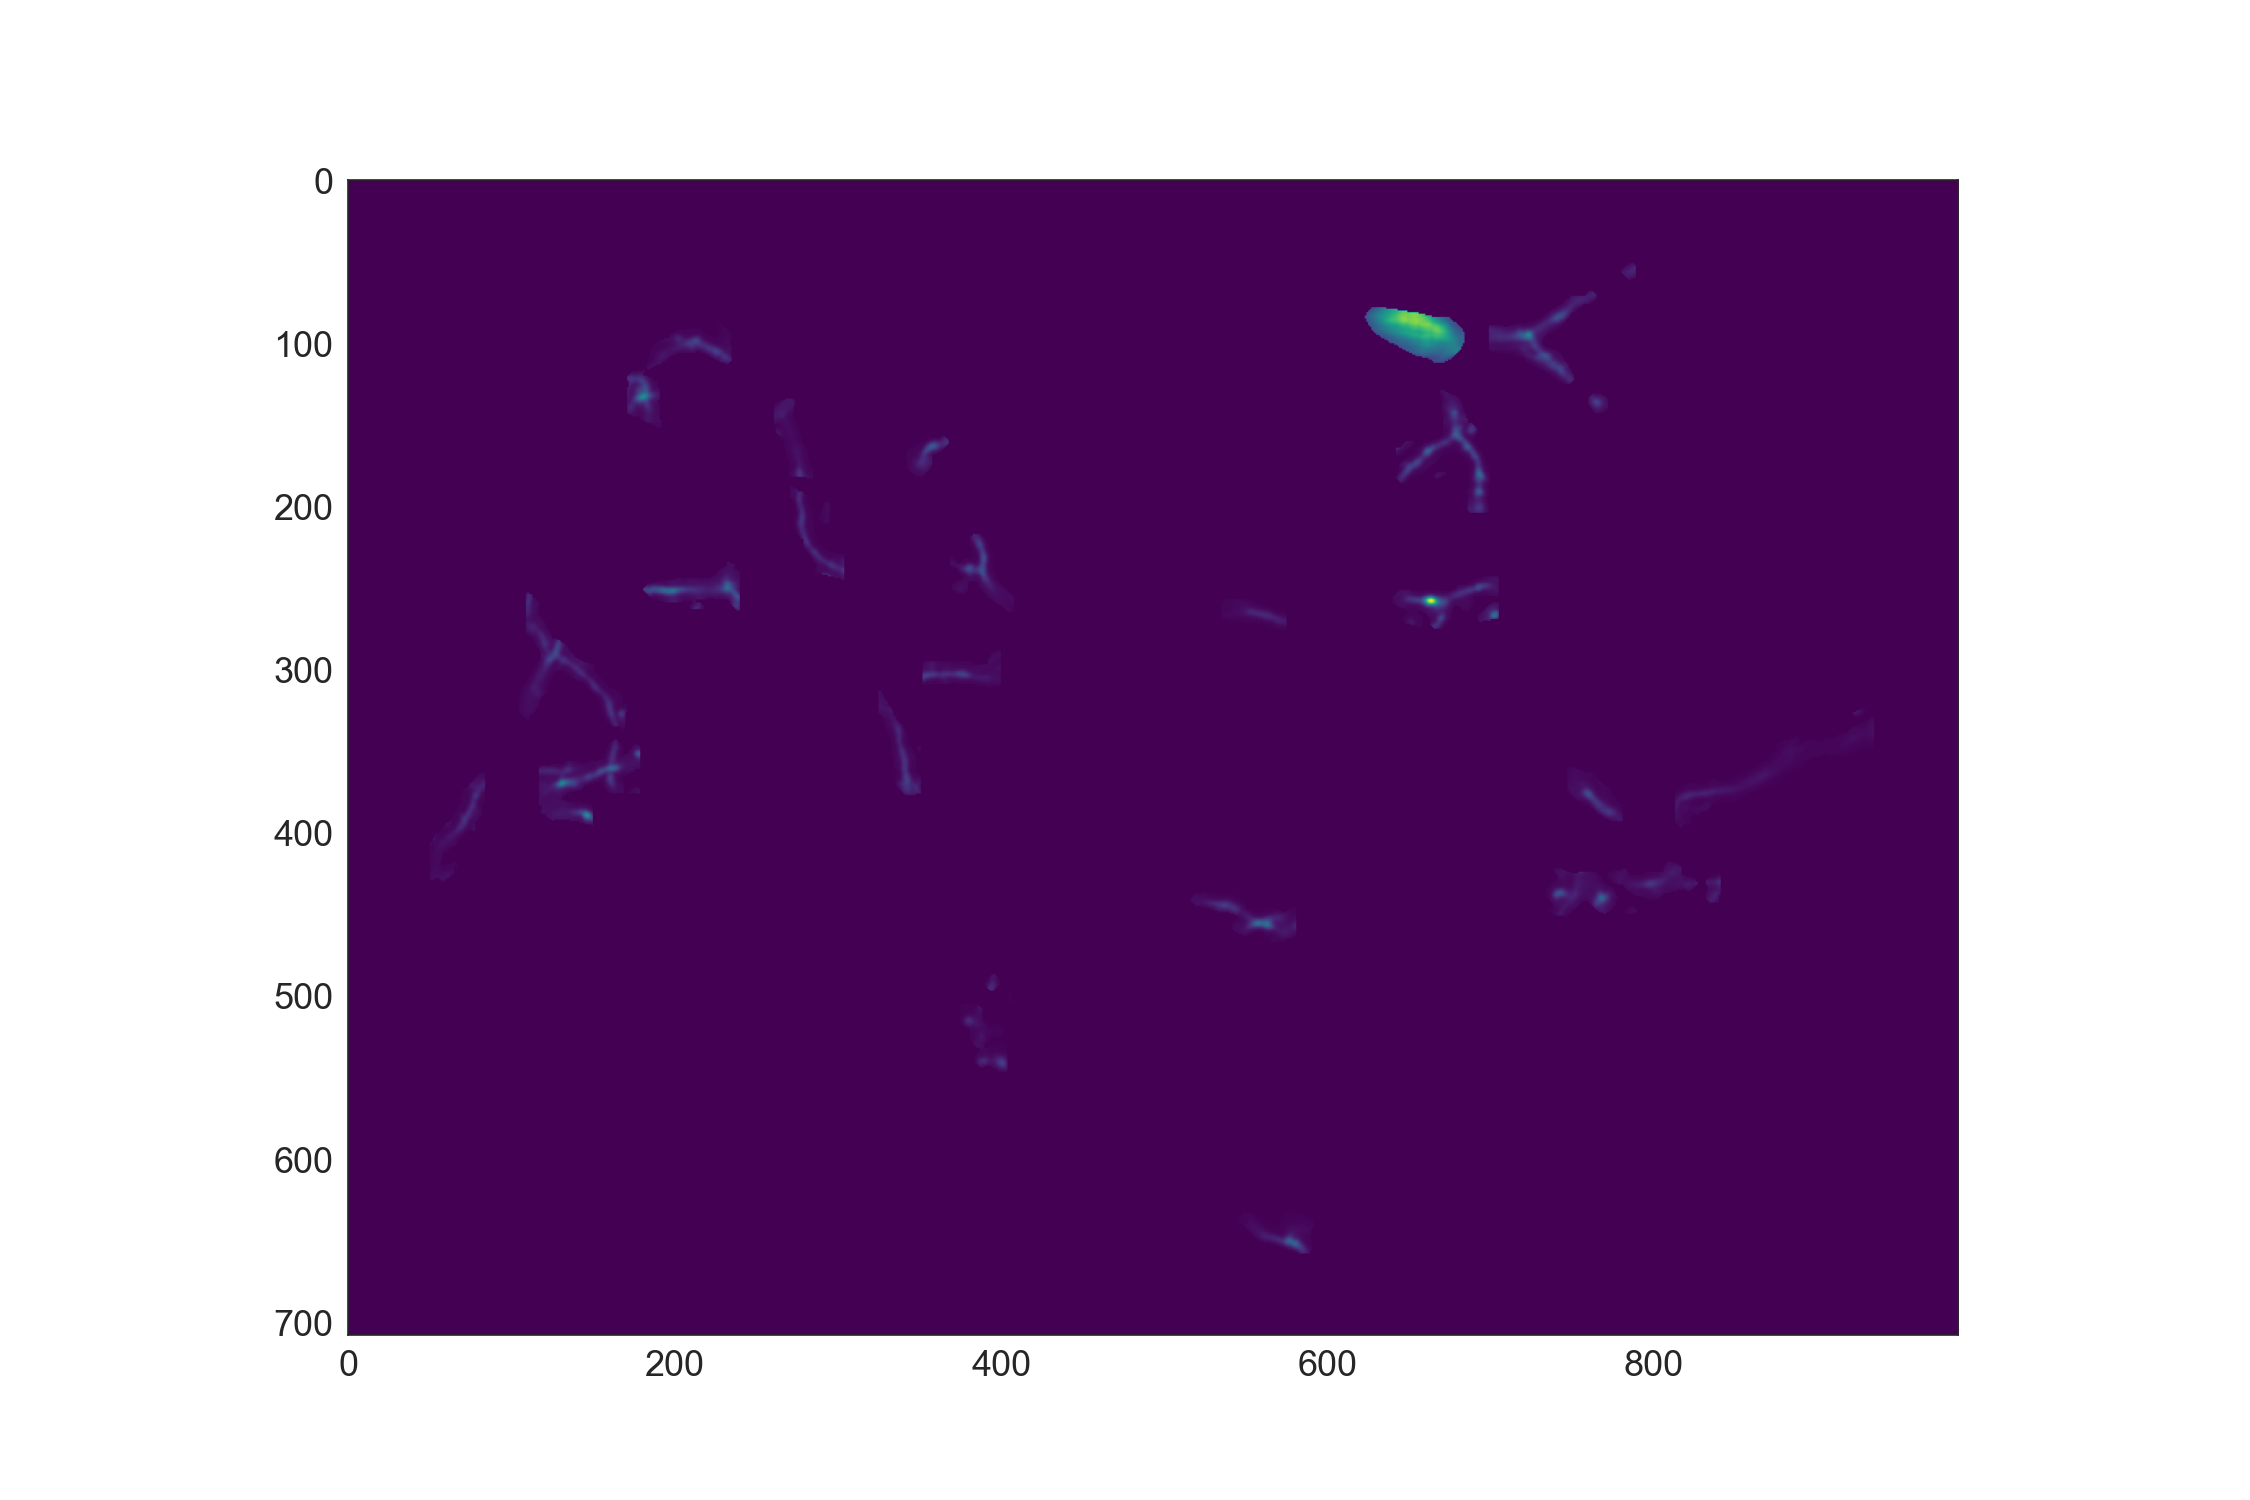

In [325]:
fig,ax=plt.subplots(figsize=(15,10))

ax.imshow(im.T,cmap='viridis')

In [326]:
valid_trials = [valid_trials_dmd1,valid_trials_dmd2]

dmd = 0

n_somas = gs.get_user_roi_traces(dmd=dmd+1,trial=valid_trials[dmd][0]).shape[0]

soma_signals = [ [] for _ in range(n_somas) ]

for trial in gs.valid_trials[dmd]:
    traces = gs.get_user_roi_traces(dmd=dmd+1,trial=trial)
    for s in range(n_somas):
        soma_signals[s].append(traces[s,1,:])    # (n_samples,)
soma_signals = [np.concatenate(chunks, axis=0) for chunks in soma_signals]

<IPython.core.display.Javascript object>


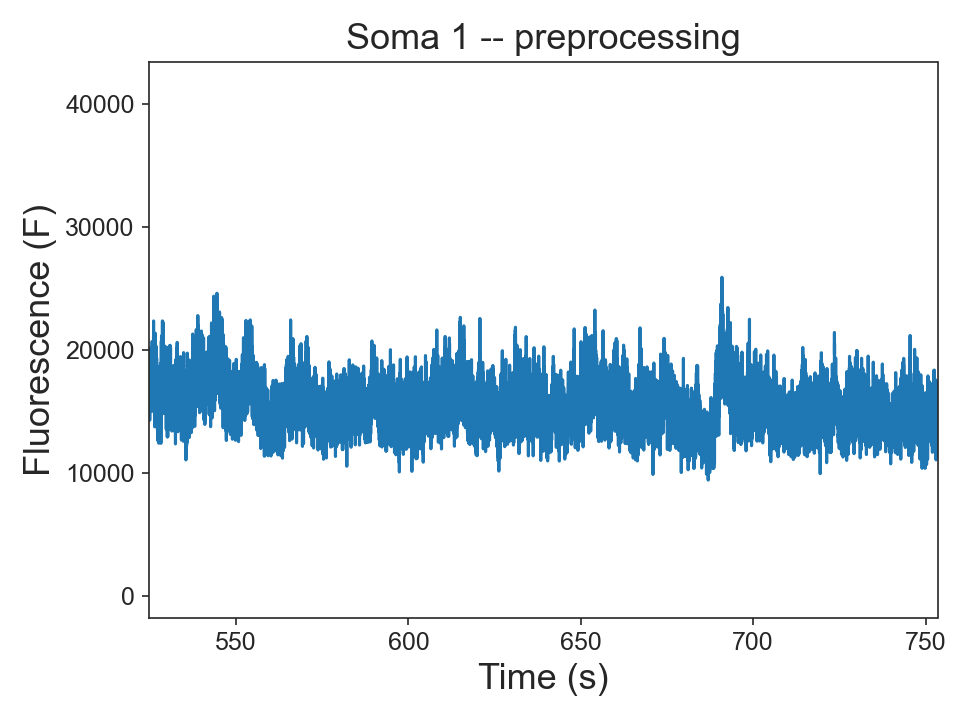

In [327]:
time = np.linspace(0,len(soma_signals[0])/200,len(soma_signals[0]))

fig,ax=plt.subplots()

ax.tick_params(axis='x',which='major',reset=True,top=False,labelsize=12)
ax.tick_params(axis='y',which='major',reset=True,right=False,labelsize=12)

for soma in soma_signals:
    ax.plot(time,soma)
ax.set_ylabel('Fluorescence (F)')
ax.set_xlabel('Time (s)')

ax.set_title('Soma 1 -- preprocessing')

fig.tight_layout()

In [339]:
out = gs.get_processed_soma_ca_all_trials(
    dmd=dmd+1,
    trace_type="Fsvd",
    fs_hz=gs.metadata["analyzeHz"],
    pad_to="max_valid",
    include_invalid=True,

    motion_correct=False,
    motion_regress_on="dF",
    motion_ridge=1e-2,
    motion_use_fields=("onlineXshift","onlineYshift","onlineZshift",
                       "motionDSr","motionDSc"
                      ),
    use_glu_as_motion_regressor=True,

    baseline_method="hull",
    denoise_window_s=2.0,   # was 1.0
    hull_window_s=90.0,     # was 30.0  (this is the big one)
    f0_floor_frac=0.05,     # was 0.02  (guardrail)

    mask_artifacts=True,
    std_factor=20.0,
    nan_pad=10,
    unmix=True,
    hp_window_s=0.5,
    ridge=1e-6,
)

In [340]:
# Key outputs (trial, roi, time)
dff = out["dff"]         # (n_trials, n_rois, Tpad)
ca_mc = out["ca_mc"]     # motion-regressed Ca
beta_unmix = out["beta_unmix"]

In [341]:
roi = 0
tr = 1
base = out["baseline"][tr-1, roi, :]
print("eps clamp fraction:", (base <= 1.0001e-6).mean())
print("baseline median:", np.nanmedian(base))

print("dff shape:", dff.shape)
print("fraction NaN (trial0, roi0):", (np.isnan(dff[0,0]).mean()))

eps clamp fraction: 0.0
baseline median: 2.741686910728082
dff shape: (65, 1, 5539)
fraction NaN (trial0, roi0): 0.012276584220978517


In [342]:
# Concatenate across ALL trials (invalid trials contribute NaNs)
dff_cat = np.concatenate([dff[tr, roi, :] for tr in range(gs.n_trials)], axis=0)

print("dF/F concat len:", dff_cat.size)
print("nan frac:", np.isnan(dff_cat).mean())
print('')

baseline_cat = np.concatenate([out['baseline'][tr, roi, :] for tr in range(gs.n_trials)], axis=0)

print("baseline concat len:", baseline_cat.size)
print("nan frac:", np.isnan(baseline_cat).mean())
print('')

df_mc_r_cat = np.concatenate([out['ca_mc'][tr, roi, :] for tr in range(gs.n_trials)], axis=0)

print("mc_r concat len:", df_mc_r_cat.size)
print("nan frac:", np.isnan(df_mc_r_cat).mean())
print('')

dF/F concat len: 360035
nan frac: 0.0029941533462024524

baseline concat len: 360035
nan frac: 0.0

mc_r concat len: 360035
nan frac: 0.0029941533462024524



<IPython.core.display.Javascript object>


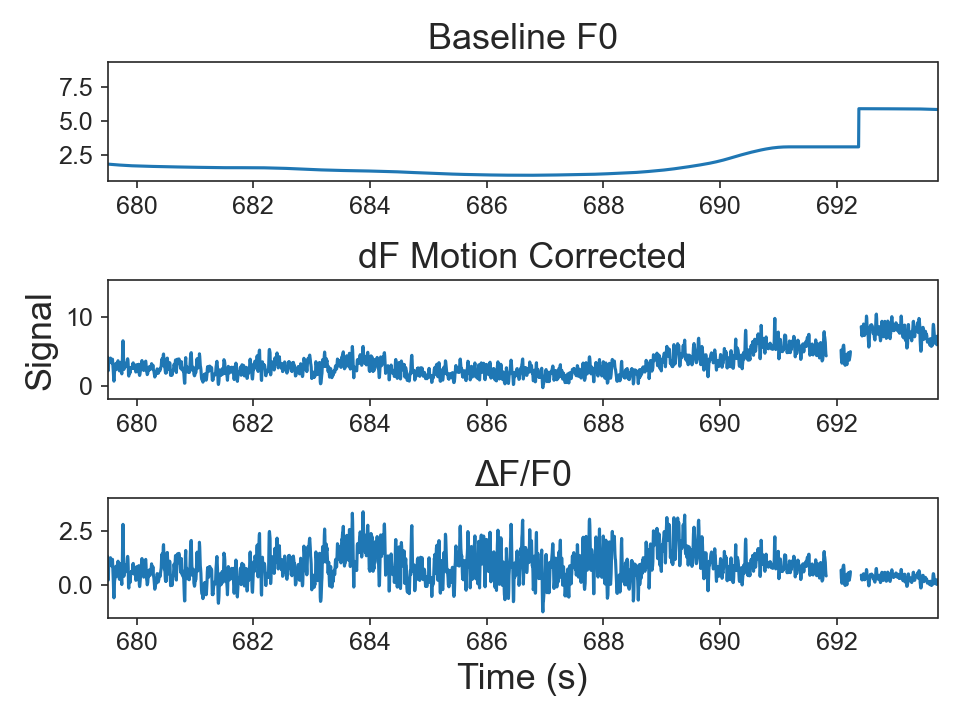

In [343]:
fig,ax = plt.subplots(3,sharex=True)

time = np.linspace(0,len(dff_cat)/200,len(dff_cat))

titles = ['Baseline F0','dF Motion Corrected','\u0394F/F0']
signals = [baseline_cat,df_mc_r_cat,dff_cat]

for i,axis in enumerate(ax.flatten()):
    axis.tick_params(axis='x',which='major',reset=True,top=False,labelsize=12)
    axis.tick_params(axis='y',which='major',reset=True,right=False,labelsize=12)
    
    axis.plot(time,signals[i])
    
    axis.set_title(titles[i])

ax[1].set_ylabel('Signal')
ax[2].set_xlabel('Time (s)')
# ax[2].set_ylim(-3,3)
fig.tight_layout()

<IPython.core.display.Javascript object>


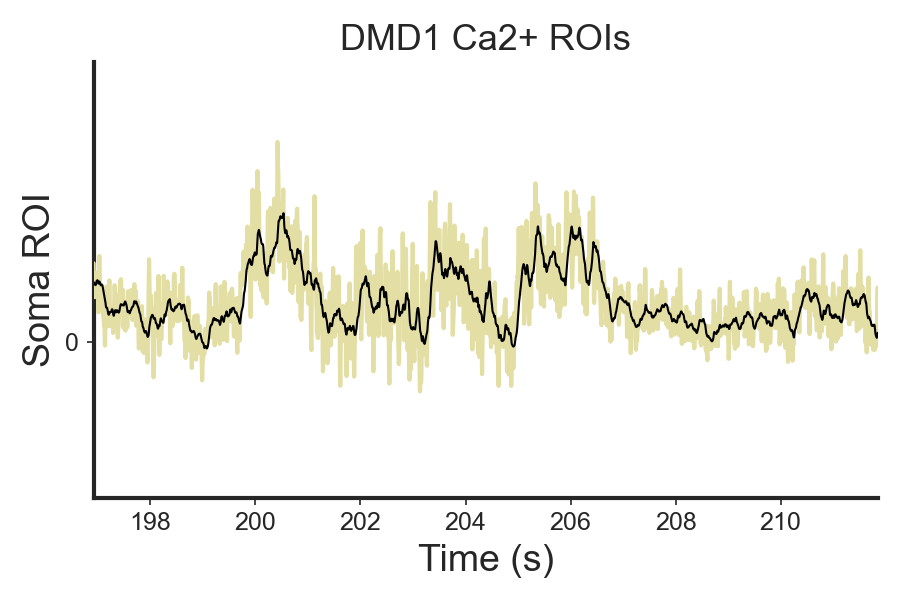

In [346]:
n_rois = np.shape(dff)[1]
offset = 0.5               # you were using i/2
fs = 200                       # Hz

cl, cmap, cp = PNW_cmap.get_PNW_cmap('Sailboat', n_colors=n_rois)

fig, ax = plt.subplots(figsize=(6, 4))
sns.despine()

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

tw = [0,1800]

for i in range(n_rois):
    # concatenate across trials for ROI i  -> (samples_total,)
    dff_ = np.concatenate([dff[tr, i] for tr in range(gs.n_trials)], axis=0)

    # If all NaN, skip plotting (but we’ll still label its tick below)
    if np.all(np.isnan(dff_)):
        continue

    time = np.arange(dff_.size) / fs

    y = dff_ + i * offset
    ax.plot(time[(time<=tw[1])&(time>tw[0])], y[(time<=tw[1])&(time>tw[0])], color=cp[i], zorder=10 - i,lw=2)

    y_smooth = pd.Series(y).rolling(25, min_periods=1).mean().to_numpy()
    ax.plot(time[(time<=tw[1])&(time>tw[0])], y_smooth[(time<=tw[1])&(time>tw[0])], color='k', zorder=10 - i,lw=1)

# Put ticks at the *offset positions*, labels are the ROI indices
yticks = np.arange(n_rois) * offset
ax.set_yticks(yticks)
ax.set_yticklabels(np.arange(n_rois))   # integer ROI indices, including 0

ax.set_ylabel('Soma ROI', fontsize=18)
ax.set_xlabel('Time (s)', fontsize=18)

for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(2)

s_bar_pad = 50    

ax.plot([tw[1]+s_bar_pad,tw[1]+s_bar_pad],[1,1.5],color='k',lw=2)
ax.text(tw[1]+s_bar_pad/5,1.0,'0.5 \u0394F/F',rotation=90)
ax.set_title(f'DMD{dmd+1} Ca2+ ROIs')
fig.tight_layout()

In [ ]:
# pd_path = r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\826033\826033_2026-02-26_12-40-54\behavior\VCO1_Behavior.harp\extracted_files\photodiode.pkl"
# stim_path = r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\826033\826033_2026-02-26_12-40-54\behavior\VCO1_Behavior.harp\bonsai_event_log.csv"
# photodiode_df = pd.read_pickle(pd_path)
# stim_df = pd.read_csv(stim_path)

In [ ]:
# from pathlib import Path
# from read_harp import HarpReader
# from aind_ophys.ophys.slap2.preprocessing import detect_epochs_adaptive

# harp_dir = Path(stim_path).parent
# harp_handler = HarpReader(harp_dir)
# df = harp_handler.reader.DigitalInputState.read()
# df['time']=df.index
# df = df.sort_values('time')
# df = df.reset_index(drop=True)

In [ ]:
# acq_time = df['time']-df['time'].iloc[0]
# acq_time = acq_time.values

In [ ]:
# print('Detecting imaging epochs...')
# gap_thresh = 0.02

# epochs = detect_epochs_adaptive(df,acq_time,min_duration=6,acq_type='continuous')

# epochs = [list(epoch) for epoch in epochs]
# for epoch in epochs:
#     epoch[2] = epoch[2] + df['time'].iloc[0] - photodiode_df.index[0]
#     epoch[3] = epoch[3] + df['time'].iloc[0] - photodiode_df.index[0]
# print(f'Number of detected epochs: {len(epochs)}')
# print(f'Average length of detected epochs: {np.mean([np.diff([e[2],e[3]]) for e in epochs])} seconds')

In [ ]:
# epochs

In [ ]:
# time = np.linspace(epochs[0][2],epochs[0][3],len(dff_cat))

# fig,ax=plt.subplots()

# ax.tick_params(axis='x',which='major',reset=True,top=False,labelsize=12)
# ax.tick_params(axis='y',which='major',reset=True,right=False,labelsize=12)

# for i,soma in enumerate(dff):
#     if i==1:
#         ax.plot(time,pd.DataFrame(dff_cat).rolling(10,min_periods=1).mean(),color='k',label='\u0394F/F')
#         ax.plot(time,pd.DataFrame(dff_cat).rolling(100,min_periods=1).mean(),color='tab:red',label='Rolling mean')
# # --- build a color map (stim_name -> color) using matplotlib's default cycle ---
# color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
# stim_to_color = {}
# color_i = 0
        
# starts = stim_df[stim_df['Value'].astype(str).str.contains(r"\.tiff", case=False, na=False)].index

# for i in starts[:50]:
#     stim_name = str(stim_df.loc[i, 'Value'])  
#     t_start = float(stim_df.loc[i, 'corrected_timestamps'])

#     # find the next EndFlash after this start
#     after = stim_df.loc[i+1:]
#     end_rows = after[after['Value'].astype(str).str.contains("EndFlash", case=False, na=False)]
#     if end_rows.empty:
#         continue
#     j = end_rows.index[0]
#     t_end = float(stim_df.loc[j, 'corrected_timestamps'])

#     # assign a color for this stimulus identity (filename string)
#     if stim_name not in stim_to_color:
#         stim_to_color[stim_name] = color_cycle[color_i % len(color_cycle)]
#         color_i += 1

#     ax.axvspan(t_start, t_end, alpha=0.25, color=stim_to_color[stim_name], lw=0)     

# ax.set_xlim(5,35)

# ax.set_ylabel('\u0394F/F',fontsize=18)
# ax.set_xlabel('Time (s)',fontsize=18)
# ax.legend(frameon=False)
# fig.tight_layout()